Saving student_performance_dataset.csv to student_performance_dataset.csv
Dataset Loaded Successfully!

DATASET PREVIEW
  Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
0       S147    Male                    31        68.267841                86   
1       S136    Male                    16        78.222927                73   
2       S209  Female                    21        87.525096                74   
3       S458  Female                    27        92.076483                99   
4       S078  Female                    37        98.655517                63   

  Parental_Education_Level Internet_Access_at_Home Extracurricular_Activities  \
0              High School                     Yes                        Yes   
1                      PhD                      No                         No   
2                      PhD                     Yes                         No   
3                Bachelors                      No                   

/tmp/ipykernel_2626/3074377906.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(data[column].mode()[0], inplace=True)
/tmp/ipykernel_2626/3074377906.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T


MODEL ACCURACY
100.00%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


FEATURE IMPORTANCE
                      Feature  Importance
7            Final_Exam_Score    0.681969
3            Past_Exam_Scores    0.111298
2             Attendance_Rate    0.096248
1        Study_Hours_per_Week    0.076139
4    Parental_Education_Level    0.013236
6  Extracurricular_Activities    0.008390
5     Internet_Access_at_Home    0.006556
0                      Gender    0.006164

PASS / FAIL SUMMARY
Pass Students : 146
Fail Students : 354


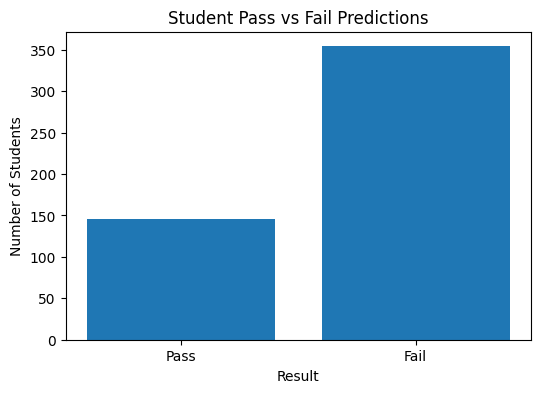

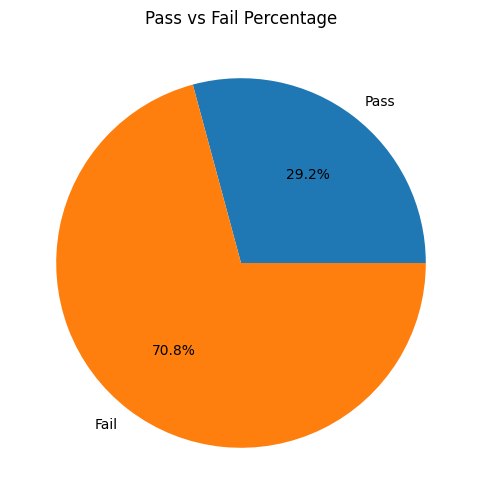

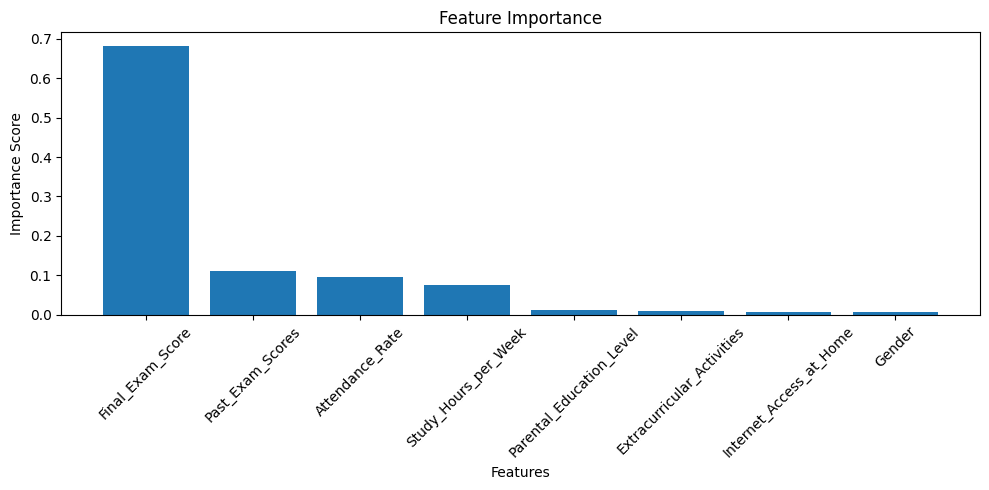


Project Executed Successfully!


In [5]:
# ==========================================
# STUDENT PERFORMANCE ANALYSIS PROJECT
# WITH PASS/FAIL PREDICTION AND CHARTS
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------
# Upload Dataset
# ------------------------------------------
uploaded = files.upload()

filename = list(uploaded.keys())[0]

data = pd.read_csv(filename)

print("Dataset Loaded Successfully!")

print("\n================================")
print("DATASET PREVIEW")
print("================================")
print(data.head())

# ------------------------------------------
# Check Missing Values
# ------------------------------------------
print("\n================================")
print("MISSING VALUES")
print("================================")
print(data.isnull().sum())

# ------------------------------------------
# Remove Duplicates
# ------------------------------------------
data = data.drop_duplicates()

# ------------------------------------------
# Fill Missing Values
# ------------------------------------------
for column in data.columns:
    if data[column].dtype == "object":
        data[column].fillna(data[column].mode()[0], inplace=True)
    else:
        data[column].fillna(data[column].mean(), inplace=True)

# ------------------------------------------
# Encode All Categorical Columns
# ------------------------------------------
label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == "object":
        data[column] = label_encoder.fit_transform(data[column])

# ------------------------------------------
# Find Target Column
# ------------------------------------------
target_column = "Pass_Fail"

if target_column not in data.columns:
    print("\nERROR: 'Pass_Fail' column not found.")
    print("Available Columns:")
    print(data.columns)
    raise Exception("Target column missing")

# ------------------------------------------
# Remove Student ID if Present
# ------------------------------------------
if "Student_ID" in data.columns:
    data = data.drop("Student_ID", axis=1)

# ------------------------------------------
# Features and Target
# ------------------------------------------
X = data.drop(target_column, axis=1)
y = data[target_column]

# ------------------------------------------
# Train-Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# Train Model
# ------------------------------------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------------
# Predictions
# ------------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------------
# Accuracy
# ------------------------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\n================================")
print("MODEL ACCURACY")
print("================================")
print(f"{accuracy * 100:.2f}%")

print("\n================================")
print("CLASSIFICATION REPORT")
print("================================")
print(classification_report(y_test, y_pred))

# ------------------------------------------
# Feature Importance
# ------------------------------------------
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n================================")
print("FEATURE IMPORTANCE")
print("================================")
print(importance)

# ------------------------------------------
# Predict All Students
# ------------------------------------------
all_predictions = model.predict(X)

pass_count = sum(all_predictions)
fail_count = len(all_predictions) - pass_count

print("\n================================")
print("PASS / FAIL SUMMARY")
print("================================")
print("Pass Students :", pass_count)
print("Fail Students :", fail_count)

# ------------------------------------------
# BAR CHART
# ------------------------------------------
plt.figure(figsize=(6,4))
plt.bar(
    ['Pass', 'Fail'],
    [pass_count, fail_count]
)

plt.title('Student Pass vs Fail Predictions')
plt.xlabel('Result')
plt.ylabel('Number of Students')
plt.show()

# ------------------------------------------
# PIE CHART
# ------------------------------------------
plt.figure(figsize=(6,6))
plt.pie(
    [pass_count, fail_count],
    labels=['Pass', 'Fail'],
    autopct='%1.1f%%'
)

plt.title('Pass vs Fail Percentage')
plt.show()

# ------------------------------------------
# FEATURE IMPORTANCE CHART
# ------------------------------------------
plt.figure(figsize=(10,5))
plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nProject Executed Successfully!")